Testing fixed SR implementation for DGLAP PINN. First confirm that the data from the npy file does satisfy SR

# Sum Rule Test

In [41]:

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import zipfile
import copy
import time
import random
import pandas as pd
import matplotlib.pyplot as plt
#from google.colab import drive
from scipy.interpolate import CubicSpline
from mpmath import fp

SEED = 11

torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


In [35]:

# ── 0. Device ────────────────────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

# ── 1. Load data ──────────────────────────────────────────────────────────────
zip_path = '/work/JAM/rathman/trey24_no_sidis_lo.zip'

with zipfile.ZipFile(zip_path, 'r') as z:
    with z.open('trey24_no_sidis_lo.npy') as f:
        treypdf = np.load(f, allow_pickle=True).item()

# Original hybrid grid
X_orig = 10**np.linspace(-4, np.log10(0.4), 100)
X_orig = np.append(X_orig, np.linspace(0.4, 1, 101)[1:])

# upper limit tightened from 0.999 to (1 - 1e-6) for consistency
# with the virtual term domain log(1-x). Both now approach x=1 equally.
N_x = 1000
X   = np.logspace(-4, np.log10(1 - 1e-6), N_x)

Q2_vals = [1.6129, 10, 100, 500, 1000]
VAL_Q2  = 500.0
CF = 4.0 / 3.0

#Now interpolate the data for +/- 1 StD. Plot the replica means and StD.

# Interpolate JAM median and +/- 1 Std Dev bands onto the lin grid X.
treypdf_log = {}
for q2 in Q2_vals:
    uv_reps        = treypdf[q2]['uv']
    uv_mean_orig   = np.mean(uv_reps, axis=0)
    uv_std_orig    = np.std(uv_reps, axis=0)
    uv_lo_orig     = uv_mean_orig - uv_std_orig     # -1 Std Dev
    uv_hi_orig     = uv_mean_orig + uv_std_orig     # +1 Std Dev

    cs_mean = CubicSpline(X_orig, uv_mean_orig)
    cs_lo  = CubicSpline(X_orig, uv_lo_orig)
    cs_hi  = CubicSpline(X_orig, uv_hi_orig)

    treypdf_log[q2] = {
        'uv'    : cs_mean(X),   # mean on log grid
        'uv_lo' : cs_lo(X),    # -1 Std Dev on log grid
        'uv_hi' : cs_hi(X),    # +1 Std Dev on log grid
    }

print(f'N_x: {N_x} (log-spaced grid: {X.min():.2e} to {X.max():.6f})')

Device: cuda
N_x: 1000 (log-spaced grid: 1.00e-04 to 0.999999)


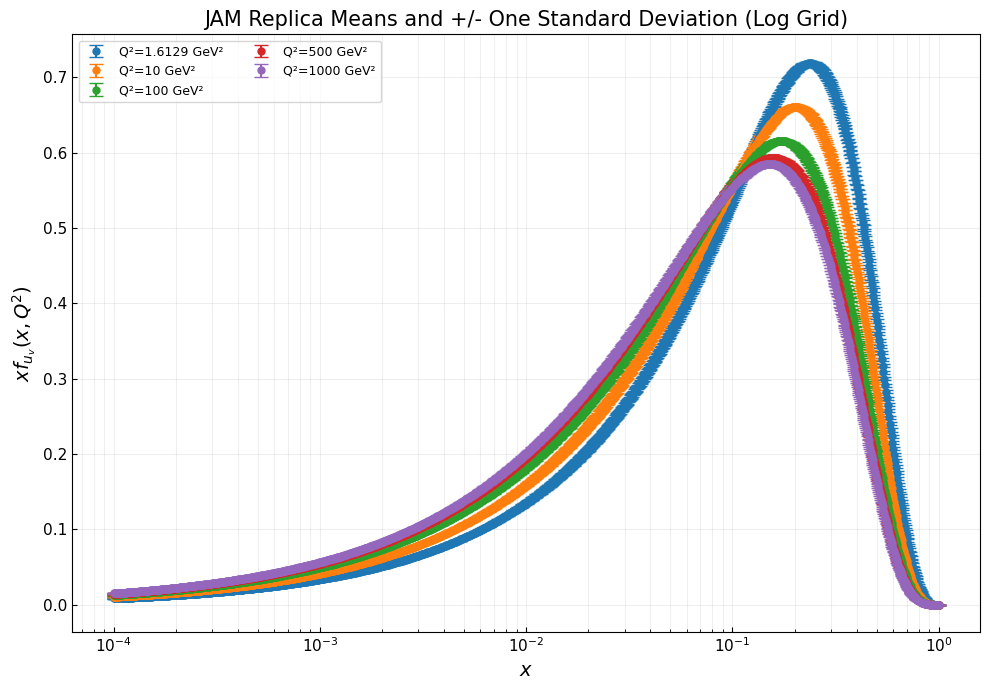

In [36]:
fig, ax = plt.subplots(figsize=(10, 7))

for q2 in Q2_vals:
    # Using the pre-interpolated log-spaced data
    uv_mean_log = treypdf_log[q2]['uv']
    uv_lo_log   = treypdf_log[q2]['uv_lo']
    uv_hi_log   = treypdf_log[q2]['uv_hi']

    # Calculate std dev from the interpolated hi/lo bands
    uv_std_log = (uv_hi_log - uv_lo_log) / 2.0

    # Plot mean with error bars representing +/- one standard deviation
    ax.errorbar(X, uv_mean_log, yerr=uv_std_log, fmt='o', capsize=5, elinewidth=1.5, markersize=5, label=f'Q²={q2} GeV²')

ax.set_xscale('log')
ax.set_xlabel(r'$x$', size=14)
ax.set_ylabel(r'$xf_{u_v}(x, Q^2)$', size=14)
ax.set_title('JAM Replica Means and +/- One Standard Deviation (Log Grid)', size=15)
ax.grid(True, which="both", ls="-", alpha=0.2)
ax.tick_params(direction='in', which='both', labelsize=11)
ax.legend(fontsize=9, loc='upper left', ncol=2)

plt.tight_layout()
plt.show()

In [37]:
# ── GL nodes for sum rule in t = -ln(x) space ───────────────────────────────
# Substitution x = e^{-t}  =>  dx = -x dt, so
#     ∫_{x_min}^{x_max} f(x) dx  =  ∫_{T_min}^{T_max} xf(x) dt
# The 1/x in f(x) = xf(x)/x cancels exactly against the Jacobian |dx/dt| = x,
# so the t-space integrand is just xf(x) -- the quantity already stored in
# treypdf -- no division by x anywhere. xf(x) ~ x^0.5 -> 0 smoothly as t -> inf,
# so there's no endpoint singularity and GL recovers its normal exponential
# convergence. This mirrors the DGLAP t=ln(y) convention already used
# elsewhere in the notebook.

from numpy.polynomial.legendre import leggauss

N_GL_SR  = 32
SR_X_MAX = 1.0            # x = 1  -> T_MIN = 0
SR_X_MIN = X_orig.min()   # 1e-4 -- stay within the JAM replica grid's support;
                          # going below this would require extrapolating the
                          # data itself, a separate question from quadrature accuracy

T_MIN = -np.log(SR_X_MAX)   # = 0
T_MAX = -np.log(SR_X_MIN)   # ≈ 9.21

gl_nodes_sr_np, gl_weights_sr_np = leggauss(N_GL_SR)

half_range_sr = (T_MAX - T_MIN) / 2.0
mid_sr        = (T_MAX + T_MIN) / 2.0

t_sr_nodes_np = mid_sr + half_range_sr * gl_nodes_sr_np   # (N_GL_SR,) in t-space
x_sr_nodes_np = np.exp(-t_sr_nodes_np)                     # mapped back to x

x_sr_nodes    = torch.tensor(x_sr_nodes_np,    dtype=torch.float32, device=device)
t_sr_nodes    = torch.tensor(t_sr_nodes_np,    dtype=torch.float32, device=device)
gl_weights_sr = torch.tensor(gl_weights_sr_np, dtype=torch.float32, device=device)
log_x_sr      = -t_sr_nodes   # ln(x) = -t, kept in case a network input needs it

print(f'SR GL nodes: {N_GL_SR}')
print(f'Integration domain (x): [{SR_X_MIN:.1e}, {SR_X_MAX:.6f}]')
print(f'Integration domain (t): [{T_MIN:.4f}, {T_MAX:.4f}]')
print(f'Jacobian (T_MAX-T_MIN)/2: {half_range_sr:.6f}')
print(f'Smallest x node: {x_sr_nodes_np.min():.3e}  (t = {t_sr_nodes_np.max():.4f})')
print(f'Largest  x node: {x_sr_nodes_np.max():.6f}  (t = {t_sr_nodes_np.min():.4f})')

SR GL nodes: 32
Integration domain (x): [1.0e-04, 1.000000]
Integration domain (t): [-0.0000, 9.2103]
Jacobian (T_MAX-T_MIN)/2: 4.605170
Smallest x node: 1.013e-04  (t = 9.1977)
Largest  x node: 0.987479  (t = 0.0126)


In [38]:
# ── Sum rule integral via GL quadrature in t-space — JAM mean check ─────────
# Integrand is xf(x) directly, evaluated at x_sr_nodes -- no 1/x division.
# Splined from X_orig directly (not the re-interpolated linear grid X), so we
# never touch the extrapolated point at x=0.

from scipy.interpolate import CubicSpline

sr_results = {}

for q2 in Q2_vals:
    uv_mean_orig = np.mean(treypdf[q2]['uv'], axis=0)
    cs_jam = CubicSpline(X_orig, uv_mean_orig)

    xf_sr_np = cs_jam(x_sr_nodes.cpu().numpy())            # (N_GL_SR,) -- this IS xf(x)
    xf_sr    = torch.tensor(xf_sr_np, dtype=torch.float32, device=device)

    # Weighted sum with t-space Jacobian -- no division by x_sr_nodes anywhere
    integral_val = (gl_weights_sr * xf_sr * half_range_sr).sum().item()

    sr_results[q2] = integral_val
    deviation      = integral_val - 2.0
    print(f'Q² = {q2:>8.4f} GeV²  |  ∫uv dx = {integral_val:.6f}  '
          f'(dev from 2.0: {deviation:+.6f}  |  {abs(deviation)/2.0*100:.4f}%)')

print()
print(f'Note: integration domain is x ∈ [{SR_X_MIN:.1e}, {SR_X_MAX:.6f}]')
print('This does not cover the JAM grid below 1e-4 -- deviations from 2.0 near')
print('~0.1% now reflect that missing low-x tail, not quadrature error.')

Q² =   1.6129 GeV²  |  ∫uv dx = 1.985933  (dev from 2.0: -0.014067  |  0.7033%)
Q² =  10.0000 GeV²  |  ∫uv dx = 1.982350  (dev from 2.0: -0.017650  |  0.8825%)
Q² = 100.0000 GeV²  |  ∫uv dx = 1.978321  (dev from 2.0: -0.021679  |  1.0839%)
Q² = 500.0000 GeV²  |  ∫uv dx = 1.975719  (dev from 2.0: -0.024281  |  1.2141%)
Q² = 1000.0000 GeV²  |  ∫uv dx = 1.974643  (dev from 2.0: -0.025357  |  1.2679%)

Note: integration domain is x ∈ [1.0e-04, 1.000000]
This does not cover the JAM grid below 1e-4 -- deviations from 2.0 near
~0.1% now reflect that missing low-x tail, not quadrature error.


# Sum Rule with extended Low-x data

The SR integral disagreement appears to be from the missing low-x tail. To test this, JAM PDFs have been sampled on x from [10^-8, 1]. The above numerical integration will now be repeated with this extended boundary to see if this solves the issue. 

In [42]:
# ── 0. Device ─────────────────────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

# ── 1. Load data ──────────────────────────────────────────────────────────────
# MODIFIED: new file trey24_no_sidis_lo_ext_x.npy is on a purely log-spaced
# grid that matches X directly. CubicSpline interpolation is therefore not
# needed — treypdf_log is populated by reading the arrays directly.

NPY_PATH = '/work/JAM/rathman/PINN4QCD/Notebooks/trey24_no_sidis_lo_ext_xq2.npy'
treypdf  = np.load(NPY_PATH, allow_pickle=True).item()   

# ── 2. x-grid — must match the grid in the new npy file exactly ──────────────
N_x   = 200
X     = 10**np.linspace(-8, np.log10(1), N_x)

log_x = np.log(X)

Q2_vals = [1.6129, 10, 100, 500, 1000]
VAL_Q2  = 500.0
CF      = 4.0 / 3.0

# ── 3. Build treypdf_log directly from file arrays ────────────────────────────
# We compute mean and ±1 std dev from the replica ensemble as before.
treypdf_log = {}
for q2 in Q2_vals:
    uv_reps  = treypdf[q2]['uv']              # (n_replicas, N_x) — already on X

    uv_mean  = np.mean(uv_reps, axis=0)       # (N_x,)
    uv_std   = np.std(uv_reps,  axis=0)       # (N_x,)

    treypdf_log[q2] = {
        'uv'    : uv_mean,                    # mean  — no interpolation needed
        'uv_lo' : uv_mean - uv_std,           # -1 std dev
        'uv_hi' : uv_mean + uv_std,           # +1 std dev
    }

print(f'Loaded: {NPY_PATH}')
print(f'N_x: {N_x}  |  x grid: {X.min():.2e} to {X.max():.8f}')
print(f'Q² values: {Q2_vals}')
print(f'Replica shape at Q²=1.6129: {treypdf[1.6129]["uv"].shape}')
print(f'  → should be (n_replicas, {N_x})')

Device: cuda
Loaded: /work/JAM/rathman/PINN4QCD/Notebooks/trey24_no_sidis_lo_ext_xq2.npy
N_x: 200  |  x grid: 1.00e-08 to 1.00000000
Q² values: [1.6129, 10, 100, 500, 1000]
Replica shape at Q²=1.6129: (1196, 200)
  → should be (n_replicas, 200)


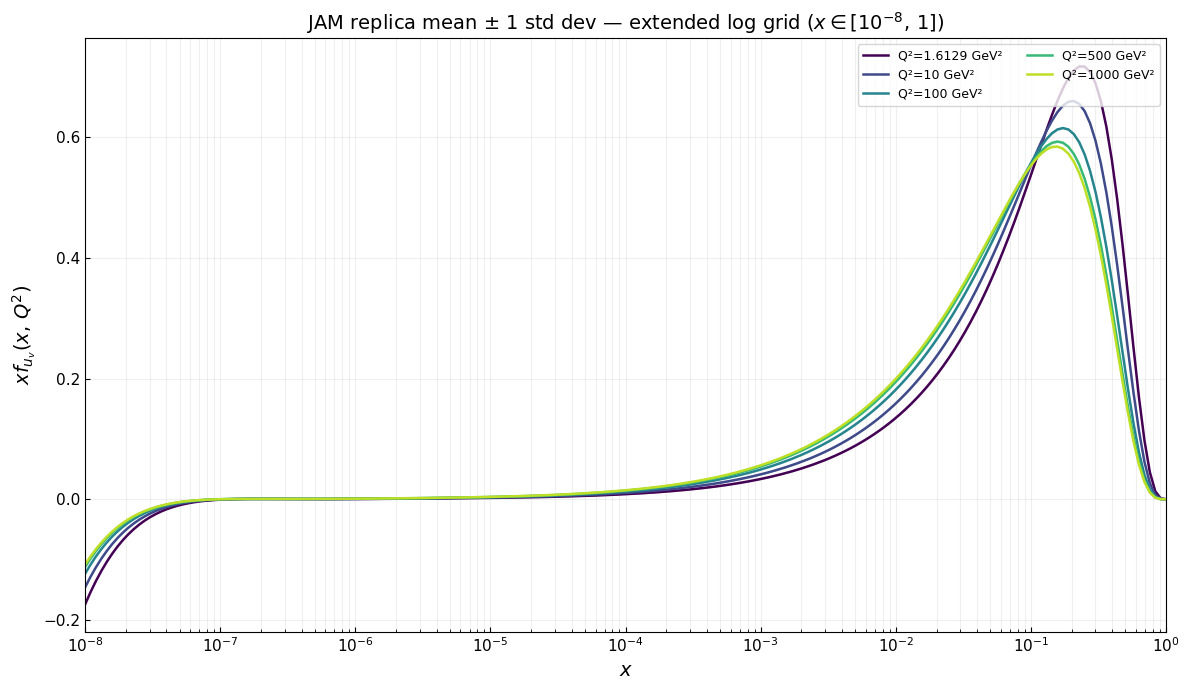

In [43]:
fig, ax = plt.subplots(figsize=(12, 7))

# Colour cycle — one colour per Q² value
colors = plt.cm.viridis(np.linspace(0, 0.9, len(Q2_vals)))

for q2, color in zip(Q2_vals, colors):
    uv_mean = treypdf_log[q2]['uv']
    uv_lo   = treypdf_log[q2]['uv_lo']
    uv_hi   = treypdf_log[q2]['uv_hi']

    # ±1 std dev band
    ax.fill_between(X, uv_lo, uv_hi, color=color, alpha=0.20, linewidth=0)

    # Mean curve
    ax.plot(X, uv_mean, color=color, lw=1.8, label=f'Q²={q2} GeV²')

ax.set_xscale('log')
ax.set_xlim(X.min(), X.max())   # reflects extended grid: 1e-8 to ~1
#ax.set_ylim(bottom=0)
ax.set_xlabel(r'$x$', fontsize=14)
ax.set_ylabel(r'$xf_{u_v}(x,\,Q^2)$', fontsize=14)
ax.set_title('JAM replica mean ± 1 std dev — extended log grid '
             r'($x \in [10^{-8},\, 1]$)', fontsize=14)
ax.grid(True, which='both', ls='-', alpha=0.2)
ax.tick_params(direction='in', which='both', labelsize=11)
ax.legend(fontsize=9, loc='upper right', ncol=2)

plt.tight_layout()
plt.show()

Why does the uv PDF become negative after 10^-7? I will only integrate from x on [10^-7, 1] to avoid this region. 

In [44]:
# ── GL nodes for sum rule in t = -ln(x) space ───────────────────────────────
# Substitution x = e^{-t}  =>  dx = -x dt, so
#     ∫_{x_min}^{x_max} f(x) dx  =  ∫_{T_min}^{T_max} xf(x) dt
# The 1/x in f(x) = xf(x)/x cancels exactly against the Jacobian |dx/dt| = x,
# so the t-space integrand is just xf(x) -- the quantity already stored in
# treypdf -- no division by x anywhere. xf(x) ~ x^0.5 -> 0 smoothly as t -> inf,
# so there's no endpoint singularity and GL recovers its normal exponential
# convergence. This mirrors the DGLAP t=ln(y) convention already used
# elsewhere in the notebook.

from numpy.polynomial.legendre import leggauss

N_GL_SR  = 32
SR_X_MAX = 1.0            # x = 1  -> T_MIN = 0
SR_X_MIN = 1e-7           # avoid negative PDF at x < 1e-7

T_MIN = -np.log(SR_X_MAX)   # = 0
T_MAX = -np.log(SR_X_MIN)   

gl_nodes_sr_np, gl_weights_sr_np = leggauss(N_GL_SR)

half_range_sr = (T_MAX - T_MIN) / 2.0
mid_sr        = (T_MAX + T_MIN) / 2.0

t_sr_nodes_np = mid_sr + half_range_sr * gl_nodes_sr_np   # (N_GL_SR,) in t-space
x_sr_nodes_np = np.exp(-t_sr_nodes_np)                     # mapped back to x

x_sr_nodes    = torch.tensor(x_sr_nodes_np,    dtype=torch.float32, device=device)
t_sr_nodes    = torch.tensor(t_sr_nodes_np,    dtype=torch.float32, device=device)
gl_weights_sr = torch.tensor(gl_weights_sr_np, dtype=torch.float32, device=device)
log_x_sr      = -t_sr_nodes   # ln(x) = -t, kept in case a network input needs it

print(f'SR GL nodes: {N_GL_SR}')
print(f'Integration domain (x): [{SR_X_MIN:.1e}, {SR_X_MAX:.6f}]')
print(f'Integration domain (t): [{T_MIN:.4f}, {T_MAX:.4f}]')
print(f'Jacobian (T_MAX-T_MIN)/2: {half_range_sr:.6f}')
print(f'Smallest x node: {x_sr_nodes_np.min():.3e}  (t = {t_sr_nodes_np.max():.4f})')
print(f'Largest  x node: {x_sr_nodes_np.max():.6f}  (t = {t_sr_nodes_np.min():.4f})')

SR GL nodes: 32
Integration domain (x): [1.0e-07, 1.000000]
Integration domain (t): [-0.0000, 16.1181]
Jacobian (T_MAX-T_MIN)/2: 8.059048
Smallest x node: 1.022e-07  (t = 16.0960)
Largest  x node: 0.978191  (t = 0.0221)


In [34]:
# ── Sum rule integral via GL quadrature in t-space — JAM mean check ─────────
# Integrand is xf(x) directly, evaluated at x_sr_nodes -- no 1/x division.
# Splined from X_orig directly, so we
# never touch the extrapolated point at x=0.

from scipy.interpolate import CubicSpline

sr_results = {}

for q2 in Q2_vals:
    uv_mean_orig = np.mean(treypdf[q2]['uv'], axis=0)
    cs_jam = CubicSpline(X, uv_mean_orig)

    xf_sr_np = cs_jam(x_sr_nodes.cpu().numpy())            # (N_GL_SR,) -- this IS xf(x)
    xf_sr    = torch.tensor(xf_sr_np, dtype=torch.float32, device=device)

    # Weighted sum with t-space Jacobian -- no division by x_sr_nodes anywhere
    integral_val = (gl_weights_sr * xf_sr * half_range_sr).sum().item()

    sr_results[q2] = integral_val
    deviation      = integral_val - 2.0
    print(f'Q² = {q2:>8.4f} GeV²  |  ∫uv dx = {integral_val:.6f}  '
          f'(dev from 2.0: {deviation:+.6f}  |  {abs(deviation)/2.0*100:.4f}%)')

print()
print(f'Note: integration domain is x ∈ [{SR_X_MIN:.1e}, {SR_X_MAX:.6f}]')

Q² =   1.6129 GeV²  |  ∫uv dx = 2.000036  (dev from 2.0: +0.000036  |  0.0018%)
Q² =  10.0000 GeV²  |  ∫uv dx = 1.999983  (dev from 2.0: -0.000017  |  0.0008%)
Q² = 100.0000 GeV²  |  ∫uv dx = 1.999906  (dev from 2.0: -0.000094  |  0.0047%)
Q² = 500.0000 GeV²  |  ∫uv dx = 1.999853  (dev from 2.0: -0.000147  |  0.0073%)
Q² = 1000.0000 GeV²  |  ∫uv dx = 1.999830  (dev from 2.0: -0.000170  |  0.0085%)

Note: integration domain is x ∈ [1.0e-07, 1.000000]
